In [1]:
%run Ch04_GPT.ipynb
%run Ch02_Loading_Data.ipynb
%run GPT_CONFIG_124M_Modified.ipynb

In [2]:
file_path = "the-verdict.txt"

with open(file_path, 'r', encoding="utf-8") as f:
  text_data = f.read()

In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

In [5]:
print("Total Characters =>", total_characters)
print("Total Tokens =>", total_tokens)

Total Characters => 20479
Total Tokens => 5145


In [6]:
# Splitting Text into Training and Validation Data

train_ratio = 0.90
split_idx = int(train_ratio * total_characters)

train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [7]:
train_loader = createDataLoaderV1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = createDataLoaderV1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [8]:
print("Train Loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train Loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [9]:
print("Validation Loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Validation Loader:
torch.Size([2, 256]) torch.Size([2, 256])


<div align="center">
  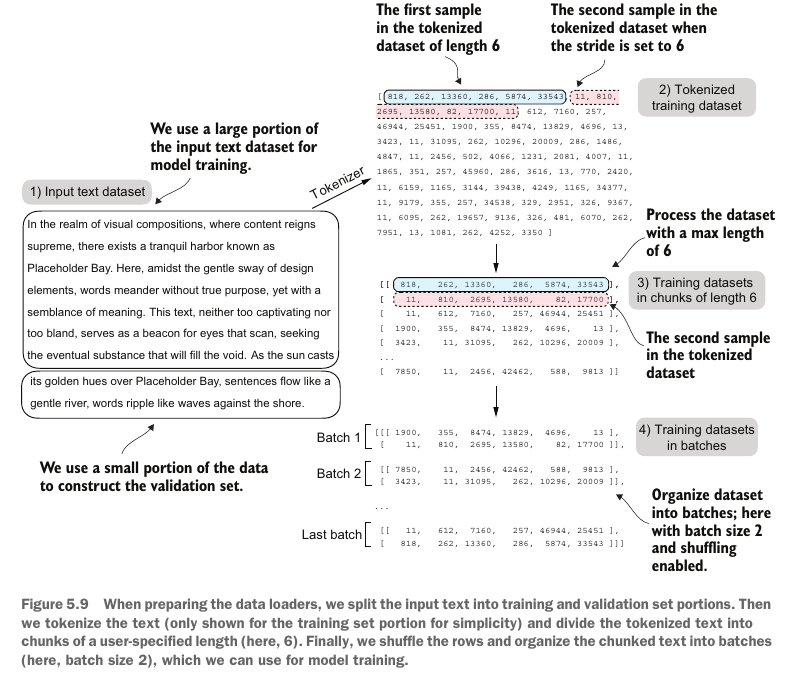
</div>

In [10]:
# Loss for a Single Batch

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [11]:
# Average Loss for a User Specified Number of Batches in a DataLoader

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
        
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # if num_batches > total batches in the data loader, adjust num_batches
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    
    return total_loss / num_batches

In [15]:
# Sanity Check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [16]:
# Another Optional Check

train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training Tokens =>", train_tokens)
print("Validation Tokens =>", val_tokens)
print("All Tokens =>", train_tokens + val_tokens)

Training Tokens => 4608
Validation Tokens => 512
All Tokens => 5120


In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available()              # NVIDIA GPUs
    else "mps" if torch.backends.mps.is_available()  # Apple GPUs
    else "cpu")

In [14]:
print(f"Using {device} Device.")

Using cpu Device.


In [18]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.eval(); # disables dropout since we are not training the model

In [19]:
model.to(device) # No Assignment, model = model.to(device) necessary for nn.Module classes

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

In [20]:
print("Training Loss =>", train_loss)
print("Validation Loss =>", val_loss)

Training Loss => 10.987583584255642
Validation Loss => 10.98110580444336
